In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')
# Python libraries
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel


from TEXAS.utils import get_repo_root


import TEXAS
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.stan.invT import predict_temperature_from_RI
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial



Python 3.10.13
0.1.0


In [2]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/TEXAS /home/micromamba/app/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient


def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX
## Logistic equations
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'
    
def pred_texRI(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

# Data

In [4]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [5]:
fpath = f'{local_github_path}/spreadsheets/'
fname = 'ds03_processed_coretop_tex.csv'

raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df['scaledRI'] = raw_coretop_df['ringIndex']/4
raw_coretop_df['deltaRI_group'] = pd.cut(raw_coretop_df['deltaRI'],
                                            bins=[-np.inf, -0.3, 0.3, np.inf],
                                            labels=['<-0.3','-0.3 to 0.3','>0.3'])

raw_coretop_df['pred_new_texRI'] = pred_texRI(raw_coretop_df['TEX86'], method_name='exp_thisStudy')
raw_coretop_df['new_deltaRI'] = raw_coretop_df['scaledRI'] - raw_coretop_df['pred_new_texRI']
raw_coretop_df

,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,thermocline_nitrate,thermocline_nitrate_depthIntegral,region_ID,regionName,mahalanobis_distance,mahalanobis_distance_weights,mahalanobis_outlier,deltaRI_group,pred_new_texRI,new_deltaRI
0,RR00001,JET_RR_00001,GeoB7702-3,GC,5.0,6.0,31.651700,34.07330,562.0,0.662000,...,0.003865,0.025728,NaN,NaN,NaN,NaN,NaN,NaN,2.649848,NaN
1,RR00002,JET_RR_00002,KNR195-5-5 MC11,MC,6.0,8.0,-1.532700,-86.78520,2288.0,0.602873,...,8.300386,5.318187,10.0,East Equatorial Pacific,1.886982,0.894152,False,-0.3 to 0.3,2.434261,-1.848859
2,RR00003,JET_RR_00003,KNR195-5-6 MC12,MC,0.0,1.0,-3.710500,-81.11530,378.0,0.570000,...,5.804398,4.208444,NaN,NaN,NaN,NaN,NaN,NaN,2.322082,NaN
3,RR00004,JET_RR_00004,KNR195-5-7 MC16,MC,0.0,1.0,-3.750200,-81.13580,379.0,0.572000,...,7.112034,5.378340,NaN,NaN,NaN,NaN,NaN,NaN,2.328756,NaN
4,RR00005,JET_RR_00005,KNR195-5-8 MC18,MC,4.0,6.0,-3.969000,-81.31000,1024.0,0.599447,...,6.462469,4.969550,10.0,East Equatorial Pacific,1.217141,0.946764,False,-0.3 to 0.3,2.422321,-1.780690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2077,RR02080,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.600000,-65.40000,267.0,0.400000,...,3.155563,3.107517,60.0,Baffin Bay,4.267857,0.707148,False,>0.3,1.819351,-1.520851
2078,RR02081,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.410000,-64.40000,1054.0,0.322581,...,3.043328,2.995078,60.0,Baffin Bay,3.700127,0.751740,False,>0.3,1.628025,-1.355025
2079,RR02082,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.970000,-59.49000,1012.0,0.375000,...,2.829360,2.795761,60.0,Baffin Bay,4.128651,0.718082,False,>0.3,1.755230,-1.450230
2080,RR02083,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.0,3.0,-31.584330,164.44867,2131.0,0.671171,...,0.917937,0.575588,61.0,Tasman Sea,1.925943,0.891092,False,-0.3 to 0.3,2.684958,-2.062401


In [6]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))

fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/'
fname = 'woa23_decav91C0_t00_04.nc'
woa23_decav91C0_t00_04 = xr.open_dataset(os.path.join(fpath, fname),decode_times=False)
SST = woa23_decav91C0_t00_04['t_an'].sel(depth=0).rename('sst')
ocean_properties_ds['sst'] = SST.drop_vars('depth')
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * time           (time) float32 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                    (lat: 720, lon: 1440)
Coordinates:
  * lat                        (lat) float32 -89.88 -89.62 ... 89.62 89.88
  * lon                        (lon) float32 -179.9 -179.6 ... 179.6 179.9
Data variables: (12/15)
    region_ID                  (lon, lat) float64 ...
    tex_count                  (lon, lat) float64 ...
    tex_median                 (lon, lat) float64 ...
    tex_mean                   (lon, lat) float64 ...
    tex_std                    (lon, lat) float64 ...
    scaledRI_count             (lon, lat) float64 ...
    ...                         ...
    gdgt23ratio_count          (lon, lat) float64 ...
    gdgt23ratio_median         (lon, lat) float64 ...
    gdgt23ratio_mean           (lon, lat) float64 ...
    gdgt23ratio_std            (lon, lat) float64 ...
    modernWaterDepth_mean      (lon, lat) float64 ...
    mahalanobis_distance_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [7]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])



coretop_df_temp = coretop_ds_merged.to_dataframe()
coretop_df_temp['pred_new_texRI'] = pred_texRI(coretop_df_temp['tex_median'], method_name='exp_thisStudy')
coretop_df_temp['new_deltaRI'] = coretop_df_temp['scaledRI_median']*4 - coretop_df_temp['pred_new_texRI']
coretop_df_temp = coretop_df_temp.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median',]).reset_index()
coretop_df = coretop_df_temp[coretop_df_temp['new_deltaRI'].abs()<=0.5].reset_index(drop=True)

display(coretop_df)

coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)  # remove outliers
coretop_df_below70N = coretop_df[coretop_df['lat']<70].reset_index(drop=True)

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,modernWaterDepth_mean,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,sst,pred_new_texRI,new_deltaRI
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,928.0,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,-1.64841,1.855344,0.184584
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,1081.0,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,-1.50741,1.695801,0.056499
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,332.0,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,-1.70171,1.735232,-0.091510
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,932.0,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,-1.42831,1.659622,0.073747
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,839.0,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,-1.74881,1.674860,0.115210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1350,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,3960.0,1.913307,7.489292,8.702111,-1.237260,95.0,-0.19781,-1.48951,1.750199,0.036001
1351,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4018.0,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,-1.64041,1.654927,0.181673
1352,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,3368.0,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,-1.57180,1.921330,-0.321930
1353,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,4443.0,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,-1.73371,2.100132,-0.367832


In [8]:
# Paleo-data plotting
fpath = fr'{local_github_path}/spreadsheets/fitted_models'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanSST_df['pubYear'] = PhanSST_df['LeadAuthor'] + PhanSST_df['Year'].astype(str)
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
                                        'GDGT0':'fGDGT_0',
                                        'GDGT1':'fGDGT_1',
                                        'GDGT2':'fGDGT_2',
                                        'GDGT3':'fGDGT_3',
                                        'Cren':'fGDGT_cren',
                                        'Crenisomer':'fGDGT_cren_prime'})
PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)


features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

PhanTEX_df['thermoT_linear'] = (PhanTEX_df['TEX86'] - intercept)/slope
PhanTEX_df['SST_Schouten02'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouten02')
PhanTEX_df['SST_Kim10'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='kim2010_tex86H')
PhanTEX_df
PhanAlk_df = PhanSST_df[PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
PhanAlk_df
# Checking records with both UK37 and TEX86
PhanTEX_df.columns

Index(['SampleID', 'SiteName', 'SiteHole', 'MBSF', 'MCD', 'SampleDepth',
       'Formation', 'Country', 'ContinentOcean', 'ModLat', 'ModLon', 'Age',
       'Period', 'Stage', 'StagePosition', 'Biozone', 'AgeFlag', 'TEX86',
       'ProxyType', 'ValueType', 'DiagenesisFlag', 'Taxon1', 'Taxon2',
       'Taxon3', 'Environment', 'Ecology', 'AnalyticalTechnique', 'CL', 'Mn',
       'Fe', 'Sr', 'Mg', 'Ca', 'Cawtp', 'MgCa', 'SrCa', 'MnSr', 'NBS120c',
       'Durango', 'MaximumCAI', 'ModWaterDepth', 'CleaningMethod', 'fGDGT_0',
       'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime',
       'BIT', 'dRI', 'MI', 'LeadAuthor', 'Year', 'PublicationDOI', 'DataDOI',
       'pubYear', 'ringIndex', 'scaledRI', 'gdgt23ratio', 'thermoT_linear',
       'SST_Schouten02', 'SST_Kim10'],
      dtype='object')

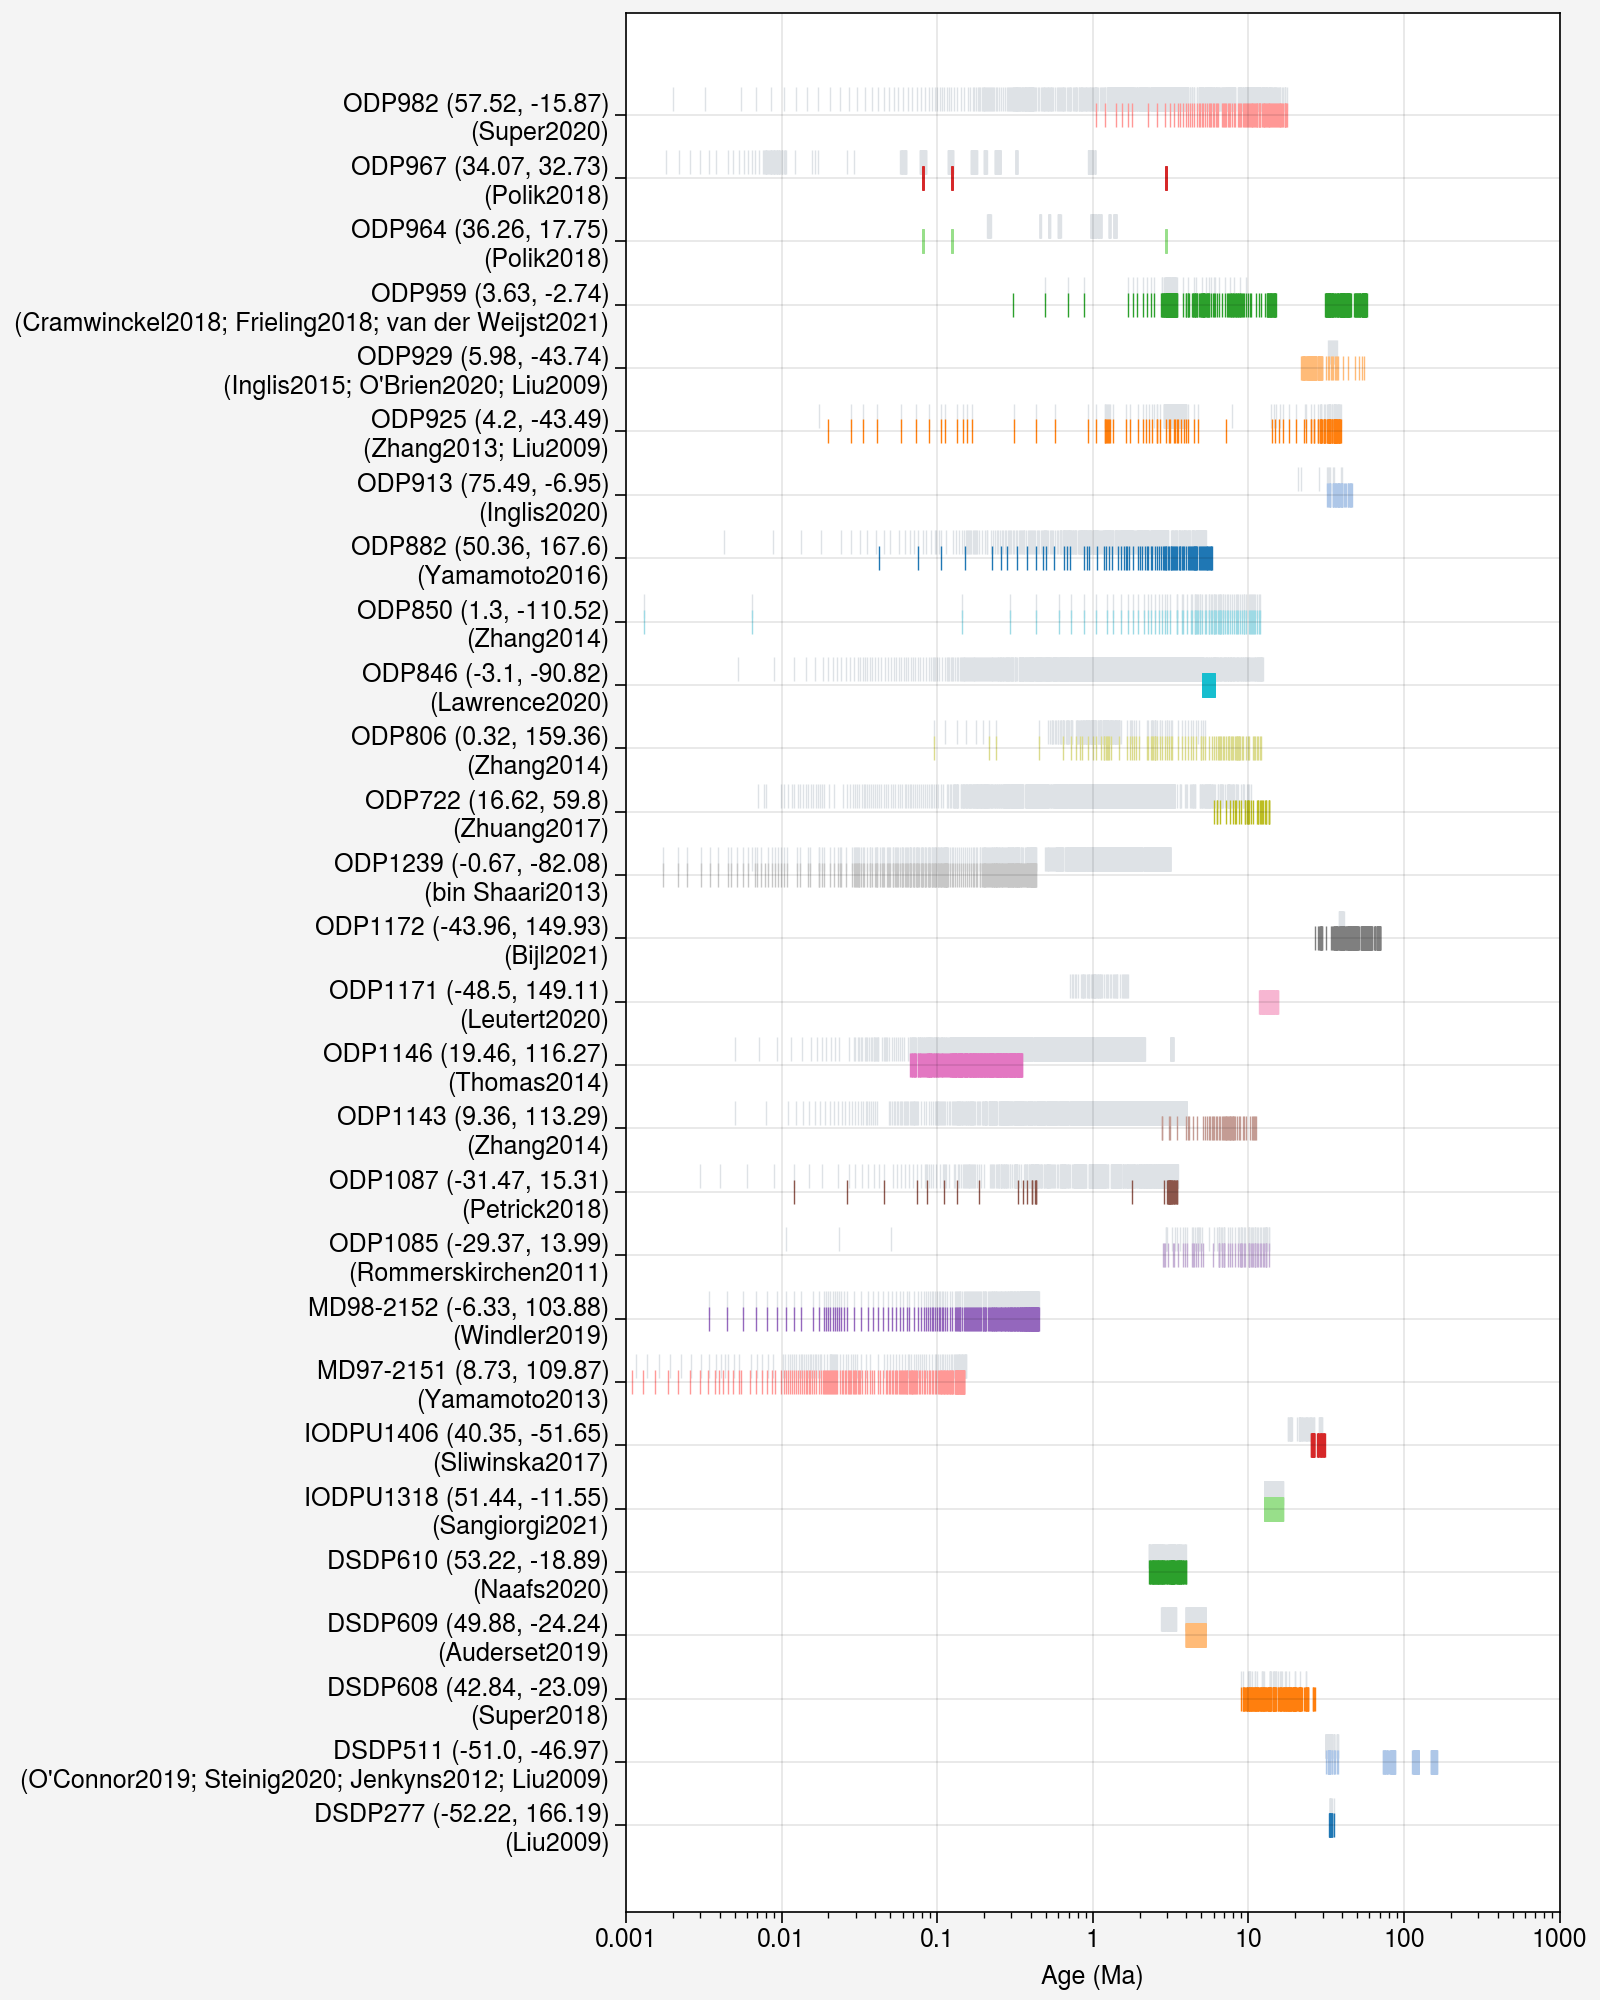

In [9]:
fig, axs = plot.subplots(width=8,height=10)
grouped_tex_df = PhanTEX_df.groupby('SiteName')

ax = axs[0]
jj = 0
y_tick_labels = []
for j, (group_name, group_data) in enumerate(grouped_tex_df):
    if group_name in PhanAlk_df['SiteName'].unique():
        # print(f"Site: {group_name}")
        if not group_data.empty:
            plot_age = group_data['Age'].values
            j_pos_array = np.full_like(plot_age, jj, dtype=float)
            ax.scatter(plot_age, j_pos_array, m='|', s=80, lw=0.5, cycle='tab20')
            
            max_age = group_data['Age'].max()
            site_lat = group_data['ModLat'].unique()[0]
            site_lon = group_data['ModLon'].unique()[0]
            pubYear = group_data['pubYear'].unique()

            label_text = f"{group_name} ({site_lat}, {site_lon})\n({'; '.join([str(year) for year in pubYear])})"
            # group_name + f' ({(site_lat)}, {(site_lon)}) [' + [f'{year};' if len(pubYear) > 1 else f'{year}' for year in pubYear] + ']',
            y_tick_labels.append(label_text)
            # ax.text(max_age+10, jj, 
            #         label_text,
            #         fontsize=8, ha='left', va='center', color='black')
            
        sel_uk_data = PhanAlk_df[PhanAlk_df['SiteName']==group_name]    
        if not sel_uk_data.empty:
            plot_age_uk = sel_uk_data['Age'].values
            j_pos_array_uk = np.full_like(plot_age_uk, jj+0.25, dtype=float)
            ax.scatter(plot_age_uk, j_pos_array_uk, m='|', s=80, lw=0.5, color='gray3', zorder=0)
            
        jj += 1
                
        
ax.format(
    xscale='log',
    xlim=(1e-3, 1e3),
    # xtickrange=(1e-4, 1e4),
    xlabel='Age (Ma)',
    yticklabels=y_tick_labels,
    yticks=np.arange(len(y_tick_labels)),
    ytickminor=False,
)

In [10]:

# # ─── prepare sample points ────────────────────────────────────────────────────
# xx = np.linspace(-4, 50, 200)

# # ─── filter & group your data ──────────────────────────────────────────────────
# plot_data = culture_meso_df[culture_meso_df['Temperature'] < 50]
# plot_data = plot_data.replace([np.inf, -np.inf], np.nan)  # replace inf with NaN
# plot_data = plot_data.dropna(subset=['scaledRI', 'Temperature'])  # drop NaN rows

# plot_coretop_data = coretop_df.dropna(subset=['t_sf2tc_avg', 'scaledRI_median']).reset_index(drop=True)

# min_count = 2
# groups = [g for g, df in plot_data.groupby('Strains_edited') if len(df) >= min_count]

# # ─── build the figure with one trace per strain per model ─────────────────────
# fig = go.Figure()

# fig.add_trace(go.Scatter(
#     x=plot_coretop_data['t_sf2tc_avg'],
#     y=plot_coretop_data['scaledRI_median'],
#     mode='markers',
#     marker=dict(color='rgba(178,178,178,1.000)', size=5),
#     name='Core-top data',
#     showlegend=True   # you can allow toggling it via legend if you like
# ))
# core_idx = 0  # index of this core-top trace

# # ─── add global fits ────────────────────────────────────────────────
# X_all = plot_data['Temperature'].values.reshape(-1,1)
# y_all = plot_data['scaledRI'].values

# # -- Linear fit --
# ols_all = LinearRegression().fit(X_all, y_all)
# y_lin_all = ols_all.predict(xx.reshape(-1,1))


# # -- Logistic fixed upper --
# p0f = [25, 0.1, 0.1]
# bf = (0, [50,1,1])
# popt_f_all, _ = curve_fit(logistic_fixed_upper, plot_data['Temperature'], plot_data['scaledRI'], p0=p0f, bounds=bf)
# y_logif_all = logistic_fixed_upper(xx, *popt_f_all)
# r2_logif_all = 1 - np.var(plot_data['scaledRI'] - logistic_fixed_upper(plot_data['Temperature'], *popt_f_all)) / np.var(plot_data['scaledRI'])

# # -- Full logistic --
# p0_all = [25,0.1,0.1,0.1]
# bnd_all = (0, [50,1,1,1])
# popt_all, _ = curve_fit(logistic, plot_data['Temperature'], plot_data['scaledRI'], p0=p0_all, bounds=bnd_all)
# y_logi_all = logistic(xx, *popt_all)
# r2_logi_all = 1 - np.var(plot_data['scaledRI'] - logistic(plot_data['Temperature'], *popt_all)) / np.var(plot_data['scaledRI'])

# ## add global fits to figure
# for model, y, r2 in [
#     ("Linear", y_lin_all, ols_all.score(X_all, y_all)),
#     ("Logistic fixed", y_logif_all, r2_logif_all),
#     ("Logistic", y_logi_all, r2_logi_all)
# ]:
#     fig.add_trace(go.Scatter(
#         x=xx, y=y,
#         mode='lines',
#         name=f"glob_cul_meso -- {model} (R$^{2}$ = {r2:.3f})",
#         visible=True
#     ))

# ### add X_all and y_all with coretop data and fit the glob_cul_meso_crtp
# X_all_full = np.concatenate((plot_coretop_data['t_sf2tc_avg'].values.reshape(-1,1), plot_data['Temperature'].values.reshape(-1,1)))
# y_all_full = np.concatenate((plot_coretop_data['scaledRI_median'].values, plot_data['scaledRI'].values))

# # -- Linear fit --
# ols_all_full = LinearRegression().fit(X_all_full, y_all_full)
# y_lin_all_full = ols_all_full.predict(xx.reshape(-1,1))
# # -- Logistic fixed upper --
# p0f_full = [25, 0.1, 0.1]
# bf_full = (0, [50,1,1])
# popt_f_all_full, _ = curve_fit(logistic_fixed_upper, np.squeeze(X_all_full), y_all_full, p0=p0f_full, bounds=bf_full)
# y_logif_all_full = logistic_fixed_upper(xx, *popt_f_all_full)
# r2_logif_all_full = 1 - np.var(y_all_full - logistic_fixed_upper(X_all_full, *popt_f_all_full)) / np.var(y_all_full)
# # -- Full logistic --
# p0_all_full = [25,0.1,0.1,0.1]
# bnd_all_full = (0, [50,1,1,1])
# popt_all_full, _ = curve_fit(logistic, np.squeeze(X_all_full), y_all_full, p0=p0_all_full, bounds=bnd_all_full)
# y_logi_all_full = logistic(xx, *popt_all_full)
# r2_logi_all_full = 1 - np.var(y_all_full - logistic(X_all_full, *popt_all_full)) / np.var(y_all_full)
# ## add global fits to figure
# for model, y, r2 in [
#     ("Linear", y_lin_all_full, ols_all_full.score(X_all_full, y_all_full)),
#     ("Logistic fixed", y_logif_all_full, r2_logif_all_full),
#     ("Logistic", y_logi_all_full, r2_logi_all_full)
# ]:
#     fig.add_trace(go.Scatter(
#         x=xx, y=y,
#         mode='lines',
#         name=f"glob_cul_meso_crtp -- {model} (R$^{2}$ = {r2:.3f})",
#         visible=True
#     ))
    
# # ─── add all your strain traces ───────────────────────────
# for strain in groups:
#     df = plot_data[plot_data['Strains_edited'] == strain]
#     X = df['Temperature'].values.reshape(-1,1)
#     y = df['scaledRI'].values
    
#     # -- Linear fit --
#     ols = LinearRegression().fit(X, y)
#     y_lin = ols.predict(xx.reshape(-1,1))
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_lin, 
#         mode='lines',
#         name=f"{strain} -- Linear (R$^{2}$ = {ols.score(X,y):.3f})",
#         visible=(strain == groups[0])  # only first strain visible initially
#     ))
    
#     # -- Logistic fixed upper --
#     p0f = [25, 0.1, 0.1]
#     bf = (0, [50,1,1])
#     popt_f, _ = curve_fit(logistic_fixed_upper, df['Temperature'], df['scaledRI'], p0=p0f, bounds=bf)
#     y_logf = logistic_fixed_upper(xx, *popt_f)
#     r2_f = 1 - np.var(df['scaledRI'] - logistic_fixed_upper(df['Temperature'], *popt_f)) / np.var(df['scaledRI'])
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_logf,
#         mode='lines',
#         name=f"{strain} -- Logistic fixed (R$^{2}$ = {r2_f:.3f})",
#         visible=False
#     ))
    
#     # -- Full logistic --
#     p0 = [25,0.1,0.1,0.1]fwd_post
#     bnd = (0, [50,1,1,1])
#     popt, _ = curve_fit(logistic, df['Temperature'], df['scaledRI'], p0=p0, bounds=bnd)
#     y_log = logistic(xx, *popt)
#     r2 = 1 - np.var(df['scaledRI'] - logistic(df['Temperature'], *popt)) / np.var(df['scaledRI'])
#     fig.add_trace(go.Scatter(
#         x=xx, y=y_log,
#         mode='lines',
#         name=f"{strain} -- Logistic (R$^{2}$ = {r2:.3f})",
#         visible=False
#     ))
    
#     # -- Always-on scatter of raw data --
#     fig.add_trace(go.Scatter(
#         x=df['Temperature'], y=df['scaledRI'],
#         mode='markers',
#         marker=dict(size=6, line=dict(width=1, color='black')),
#         name=f"{strain} -- data",
#         visible=True
#     ))
# # build a mapping strain → color
# palette1 = px.colors.qualitative.Set1
# palette2 = px.colors.qualitative.Set2

# # make one long list
# all_colors = palette1 + palette2

# # then map strains in order
# strain_colors = {
#     strain: all_colors[i % len(all_colors)]
#     for i, strain in enumerate(groups)
# }
# coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])



# coretop_df_temp = coretop_ds_merged.to_dataframe()
# coretop_df_temp['pred_new_texRI'] = pred_texRI(coretop_df_temp['tex_median'], method_name='exp_thisStudy')
# coretop_df_temp['new_deltaRI'] = coretop_df_temp['scaledRI_median']*4 - coretop_df_temp['pred_new_texRI']
# coretop_df_temp = coretop_df_temp.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median',]).reset_index()
# coretop_df = coretop_df_temp[coretop_df_temp['new_deltaRI'].abs()<=0.5].reset_index(drop=True)

# display(coretop_df)

# coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)  # remove outliers
# coretop_df_below70N = coretop_df[coretop_df['lat']<70].reset_index(drop=True)
# # now loop through all traces
# for trace in fig.data:
#     # The “cultures + mesocosm only” global fit
#     if trace.name.startswith("glob_cul_meso --"):
#         trace.update(line=dict(
#             color="black",   # pick any CSS name or hex code
#             dash="solid",        # “solid”, “dash”, “dot”, “dashdot”, etc
#             width=4              # thicker line
#         ))

#     # The “cultures + mesocosm + coretop” global fit
#     elif trace.name.startswith("glob_cul_meso_crtp --"):
#         trace.update(line=dict(
#             color="black",
#             dash="dashdot",
#             width=3
#         ))
        
#     # skip the core-top (and any other truly global or background traces)
#     elif trace.name == "Core-top data":
#         continue

#     # split off the strain name (everything before the “ – ”)
#     strain = trace.name.split(" -- ")[0]

#     # pick a color: if it’s one of our strains, use its palette color;
#     # otherwise (e.g. “Global”) fall back to black or whatever you like
#     col = strain_colors.get(strain, "black")

#     # apply to both marker & line
#     trace.update(
#         marker=dict(color=col),
#         line=dict(color=col)
#     )



# # Hide all line traces (fits) by default, leave markers visible
# for trace in fig.data:
#     if "lines" in trace.mode:
#         trace.visible = "legendonly"
#     else:
#         trace.visible = True

# # # Make “raw data” the initial visibility state:
# # for tr in fig.data:
# #     if tr.name == "Core-top data" or tr.name.endswith("-- data"):
# #         tr.visible = True
# #     else:
# #         tr.visible = False
        


# # reposition the model‐dropdown as a vertical nav bar on the left
# fig.update_layout(

#     autosize=False,     # turn off responsive “fill the container”
#     width=900,          # fixed pixel width
#     height=500,         # fixed pixel height
#     margin=dict(l=40, r=40, t=50, b=40),

#     title="Scaled RI vs Temperature",
#     xaxis_title="Temperature (°C)",
#     yaxis_title="Scaled RI",
    
#     yaxis=dict(
#         range=[0.1, 1.1],
#         autorange=False    # turn off auto‐scaling
#     ),

#     # put the legend also on the left, so users can click each strain on/off
#     legend=dict(
#         traceorder="normal",
#         orientation="v",
#         x=1.13,      # just inside the left margin
#         y=0.5,
#         xanchor="left",
#         yanchor="middle",
#         itemsizing="constant"
#     ),
#     template='seaborn',
#     font=dict(
#         family="TeX Gyre Heros",
#         size=14,
#         color="black"
#     ),
    
# )

# # lock X/Y so the units match (remove if you don’t want a 1:1 scale)
# fig.update_xaxes(constrain='domain')            # keep the X‐axis from expanding

# # set a default
# # fig.update_layout(template="plotly_white")

# fig.show()

# # in your Python script / notebook:
# fig.write_html(
#   os.path.join(local_github_path, 'html_figures', 'scaledRI_vs_Temperature.html'),
#   include_plotlyjs="cdn",   # pull Plotly.js from the CDN
#   full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
# )


In [11]:

culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture']
culture_data_full = culture_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                        'scaledRI',
                                                                                        'gdgt23ratio']).reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm']
meso_data_full = meso_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                'scaledRI',
                                                                                'gdgt23ratio']).reset_index(drop=True)

coretop_df = coretop_df.replace([np.inf, -np.inf],np.nan).dropna(subset=['scaledRI_median',
                                                                         't_sf2tc_avg',
                                                                         'no3_sf2tc_avg',
                                                                         'gdgt23ratio_median']).reset_index(drop=True)
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)
coretop_df['gdgt23ratio_median'].max()

coretop_df_low23 = coretop_df[coretop_df['gdgt23ratio_median']<5].reset_index(drop=True)
coretop_df_low23
t_cul = culture_data_full['Temperature'].astype(float).tolist() 
scaledRI_cul = culture_data_full['scaledRI'].astype(float).tolist() 
gdgt23ratio_cul = culture_data_full['gdgt23ratio'].astype(float).tolist()

t_meso = meso_data_full['Temperature'].astype(float).tolist()
scaledRI_meso = meso_data_full['scaledRI'].astype(float).tolist()
gdgt23ratio_meso = meso_data_full['gdgt23ratio'].astype(float).tolist()

t_crtp = coretop_df['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = coretop_df['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = coretop_df['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = coretop_df['no3_sf2tc_avg'].astype(float).tolist()

In [12]:
WL_paleo_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='Wilson Lake'].reset_index(drop=True)
search_tolerance = np.std(WL_paleo_tex_df['TEX86'], ddof=1) * 2
WL_paleo_tex_df['SST_bsr'] = bsr.predict_seatemp_analog(WL_paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=6,
                                                     temptype='sst',search_tol=search_tolerance,
                                                     nens=100).percentile(50)
WL_paleo_tex_df['subT_bsr'] = bsr.predict_seatemp_analog(WL_paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=6,
                                                     temptype='subt',search_tol=search_tolerance,
                                                     nens=100).percentile(50)

100%|██████████| 24/24 [00:00<00:00, 42.78it/s]


In [13]:
load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT')

<xarray.Dataset>
Dimensions:              (draw: 4000)
Coordinates:
  * draw                 (draw) int64 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
Data variables:
    t0_crtp              (draw) float64 28.71 29.46 31.77 ... 29.93 31.33 32.24
    k_crtp               (draw) float64 0.2668 0.2596 0.2943 ... 0.3002 0.3365
    b_crtp               (draw) float64 0.432 0.4296 0.4306 ... 0.4281 0.4332
    Q_crtp               (draw) float64 4.387 3.569 2.31 ... 4.123 2.809 2.065
    v_crtp               (draw) float64 2.743 2.76 3.123 ... 3.221 3.279 3.456
    sigma_scaledRI_crtp  (draw) float64 0.05175 0.05233 ... 0.05322 0.05313
    inflection_point     (draw) float64 32.49 33.37 35.64 ... 33.78 35.28 35.93
Attributes: (12/28)
    stan_model_name:              gen_logi_fixed_hier_crtp_univ_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    run_time:                     2025-08-09T11:39:59.625715
    run_duration (sec):           28.76
    temptype:                     thermoT
    ...                           ...
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1337.36
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS
    filename:                     gen_logi_fixed_hier_crtp_univ_priorApprox_t...

In [ ]:

fwd_post_list = [
    'hier_crtp_univ_thermoT_test01_cln_crtp',
    'hier_crtp_univ_sst_test01_cln_crtp',
    'hier_crtp_multiv_thermoT_gdgt23ratio_no3_1.5_test01_cln_crtp',
    'hier_crtp_multiv_sst_gdgt23ratio_no3_1.5_test01_cln_crtp',
    'gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_test01_cln_crtp',
    'gen_logi_fixed_hier_crtp_univ_priorApprox_sst_test01_cln_crtp',
    'gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5_test01_cln_crtp',
    'gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp',
]

stan_file_name_list = [
    'invT_logistic_fixed_univ',
    'invT_logistic_fixed_univ',
    'invT_logistic_fixed_multiv',
    'invT_logistic_fixed_multiv',
    'invT_gen_logi_fixed_univ',
    'invT_gen_logi_fixed_univ',
    'invT_gen_logi_fixed_multiv',
    'invT_gen_logi_fixed_multiv',
]

# temptype_list = [
#     'thermoT',
#     'sst',
#     'thermoT_gdgt23ratio',
#     'sst_gdgt23ratio',
#     'thermoT',
#     'sst',
#     'thermoT_gdgt23ratio',
#     'sst_gdgt23ratio',
# ]

for fwd_post, stan_file_name in zip(fwd_post_list, stan_file_name_list):
    # data, _ = TEXAS.stan_utils.build_invT_inputData(
    #         scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
    #         prior_mu_t= 35.0,
    #         prior_sigma_t=6,
    #         fwd_posterior_name=fwd_post,
    #         mode='ensemble',
    #         reduction="median"
    #     )
    # stan_file_name = stan_file_name
    # post_ds, diag = TEXAS.stan_utils.get_invT_posterior(data, 
    #                                             stan_file_name,
    #                                             site_name='WilsonLake',
    #                                             temptype=sel_temptype)
    # post_summ_ds = TEXAS.stan_utils.get_invT_post_quantiles(post_ds)
    # TEXAS.stan_utils.save_invT_posterior(post_summ_ds)
    
    predict_temperature_from_RI(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        prior_mu_t= 30.0,
        prior_sigma_t=6,
        fwd_posterior_name=fwd_post,
        predictors={
            'gdgt23ratio':WL_paleo_tex_df['gdgt23ratio'].values,
        },
        site_name='WilsonLake',
        save_results=True
    )
    

01:43:29 - cmdstanpy - INFO - CmdStan start processing


🔍 Automatically selected Stan file: invT_logistic_fixed_univ
| M=100 N=52
🔧 Compiling Stan model: invT_logistic_fixed_univ.stan
✅ Compiled: invT_logistic_fixed_univ.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

✅ Posterior saved to /home/micromamba/app/TEXAS/invT_posterior_cache/WilsonLake_invT_logistic_fixed_univ_thermoT.nc
✅ invT results saved: /home/micromamba/app/TEXAS/invT_posterior_cache/WilsonLake_invT_logistic_fixed_univ_thermoT.npz
🔍 Automatically selected Stan file: invT_logistic_fixed_univ
| M=100 N=52


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [ ]:
import glob
import re

fpath = f'/mnt/lab/ModelOutput/iCESM/Eoceneclimatologies'
fname = f'b.e12.B1850C5CN.f19_g16.iPETM09x.01.pop.h.1901-2000.climo.nc'

pattern = os.path.join(fpath, '*iPETM*pop.h*.nc')
### find files with iPETM and pop.h in the name
ipetm_re = re.compile(r'iPETM\d+x')


matches = glob.glob(pattern)

for fn in glob.glob(pattern):
    basename = os.path.basename(fn)
    m = ipetm_re.search(basename)
    if m:
        print(m.group(0))   # → iPETM09x
        print(basename)
    else:
        print(f"No iPETM token found in {basename}")
    
    
    ds = xr.open_dataset(fn)
    ds = ds.drop_vars(["ULONG", "ULAT"], errors="ignore")

    ds_TEMP = ds['TEMP']
    ds_TEMP['lat'] = ds_TEMP['TLAT'].copy()
    ds_TEMP['lon'] = ds_TEMP['TLONG'].copy()

    # 1. Define your target grid
    lat_out = np.arange(-90, 90.1, 1.0)
    lon_out = np.arange(0, 360.1, 1.0)
    
    ds_out = xr.Dataset({
        "lat": (["lat"], lat_out),
        "lon": (["lon"], lon_out),
    })

    # 2. Create the regridder and interpolate
    regridder = xe.Regridder(ds_TEMP, ds_out, "bilinear", periodic=True)
    field_reg = regridder(ds_TEMP)
    field_reg.name = 'TEMP'

    fpath = f'{local_github_path}/nc_files/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'
    fname = f'Zhu19_Science_EoceneSim_fullDepth_regridded_{m.group(0)}.nc'
    
    field_reg.to_netcdf(os.path.join(fpath, fname), mode='w', format='NETCDF4', unlimited_dims='time')
    print(f"Saved regridded data to {os.path.join(fpath, fname)}")
fpath = fr'{local_github_path}/nc_files/Zhu19_Science_EoceneSim'

fname = 'b.e12.B1850C5CN.f19_g16.iPETM01x.01.pop.h.TEMP.2501-2600.climo.nc'
iPETM_01x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'b.e12.B1850C5CN.f19_g16.iPETM03x.02.pop.h.TEMP.1901-2000.climo.nc'
iPETM_03x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'b.e12.B1850C5CN.f19_g16.iPETM06x.07.pop.h.TEMP.1901-2000.climo.nc'
iPETM_06x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'b.e12.B1850C5CN.f19_g16.iPETM09x.01.pop.h.TEMP.1901-2000.climo.nc'
iPETM_09x_ds = xr.open_dataset(os.path.join(fpath,fname))

fpath = fr'{local_github_path}/nc_files/Tierney22_PNAS_PETMDA'
fname = 'PETMDA_OCN_annual.nc'
PETMDA_ds = xr.open_dataset(os.path.join(fpath,fname))

prePETMDA_da = PETMDA_ds['sst'].isel(nTime=1).copy()
PETMDA_da = PETMDA_ds['sst'].isel(nTime=0).copy()

display(prePETMDA_da)
display(PETMDA_da)

<xarray.DataArray 'sst' (nLat: 384, nLon: 320)>
[122880 values with dtype=float64]
Dimensions without coordinates: nLat, nLon
Attributes:
    units:    degree C

<xarray.DataArray 'sst' (nLat: 384, nLon: 320)>
[122880 values with dtype=float64]
Dimensions without coordinates: nLat, nLon
Attributes:
    units:    degree C

In [ ]:
post_ds = load_posterior(
        'WilsonLake_invT_gen_logi_fixed_multiv_thermoT_gdgt23ratio_no3_0.0',
        cache_dir=f'{local_github_path}/TEXAS/invT_posterior_cache'
    )
post_ds['t_est'].sel(quantile=0.5)

<xarray.DataArray 't_est' (chain: 4, t_est_dim_0: 52, t_est_dim_1: 100)>
array([[[28.61035, 28.1127 , 28.3128 , ..., 29.09645, 28.57835,
         28.66985],
        [28.0066 , 27.5516 , 27.6859 , ..., 28.4509 , 27.99025,
         28.0538 ],
        [29.03555, 28.2595 , 28.3933 , ..., 29.3243 , 28.87585,
         28.89845],
        ...,
        [25.9898 , 25.65885, 25.9303 , ..., 26.4093 , 26.0513 ,
         26.1538 ],
        [27.56845, 27.1223 , 27.381  , ..., 28.008  , 27.57815,
         27.7034 ],
        [27.31495, 26.88215, 27.05625, ..., 27.6614 , 27.25255,
         27.38215]],

       [[28.71735, 27.9296 , 28.4018 , ..., 29.0313 , 28.70985,
         28.65665],
        [28.1014 , 27.5726 , 27.6805 , ..., 28.50085, 28.13085,
         28.06275],
        [28.91955, 28.3063 , 28.48865, ..., 29.26615, 28.91315,
         28.7719 ],
...
        [26.10625, 25.74445, 25.8641 , ..., 26.32135, 26.00245,
         26.03985],
        [27.6343 , 26.9693 , 27.20645, ..., 27.9428 , 27.5209 ,
         27.627  ],
        [27.39325, 26.83935, 26.97515, ..., 27.77045, 27.21235,
         27.316  ]],

       [[28.79865, 27.97065, 28.336  , ..., 29.11265, 28.60865,
         28.6466 ],
        [28.18925, 27.4499 , 27.69965, ..., 28.399  , 28.0058 ,
         28.0286 ],
        [28.78065, 28.33925, 28.53025, ..., 29.26545, 28.83835,
         28.808  ],
        ...,
        [26.20045, 25.56055, 25.90015, ..., 26.3905 , 26.03585,
         26.09705],
        [27.6797 , 27.09885, 27.3948 , ..., 27.93655, 27.55845,
         27.64555],
        [27.2562 , 26.8039 , 26.9867 , ..., 27.46225, 27.33745,
         27.2891 ]]])
Coordinates:
  * chain     (chain) int64 1 2 3 4
    quantile  float64 0.5
Dimensions without coordinates: t_est_dim_0, t_est_dim_1

In [ ]:
invT_post_ds_list = [
    'WilsonLake_invT_logistic_fixed_univ_thermoT',
    'WilsonLake_invT_logistic_fixed_univ_sst',
    'WilsonLake_invT_logistic_fixed_multiv_thermoT_gdgt23ratio_no3_0.0',
    'WilsonLake_invT_logistic_fixed_multiv_sst_gdgt23ratio_no3_0.0',
    'WilsonLake_invT_gen_logi_fixed_univ_thermoT',
    'WilsonLake_invT_gen_logi_fixed_univ_sst',
    'WilsonLake_invT_gen_logi_fixed_multiv_thermoT_gdgt23ratio_no3_0.0',
    'WilsonLake_invT_gen_logi_fixed_multiv_sst_gdgt23ratio_no3_0.0',
    
]

new_col_names = [
    'invT_hier_univ_thermoT',
    'invT_hier_univ_sst',
    'invT_hier_multiv_thermoT_gdgt23ratio',
    'invT_hier_multiv_sst_gdgt23ratio',
    'invT_gen_logi_fixed_univ_thermoT',
    'invT_gen_logi_fixed_univ_sst',
    'invT_gen_logi_fixed_multiv_thermoT_gdgt23ratio',
    'invT_gen_logi_fixed_multiv_sst_gdgt23ratio',
]

for sel_invT_post_ds, new_col_name in zip(invT_post_ds_list, new_col_names):
    post_ds = load_posterior(
        sel_invT_post_ds,
        cache_dir=f'{local_github_path}/TEXAS/invT_posterior_cache'
    )
    WL_paleo_tex_df[new_col_name] = post_ds['t_est'].sel(quantile=0.5).values

ValueError: Length of values (4) does not match length of index (52)

KeyError: 'invT_hier_univ_thermoT'

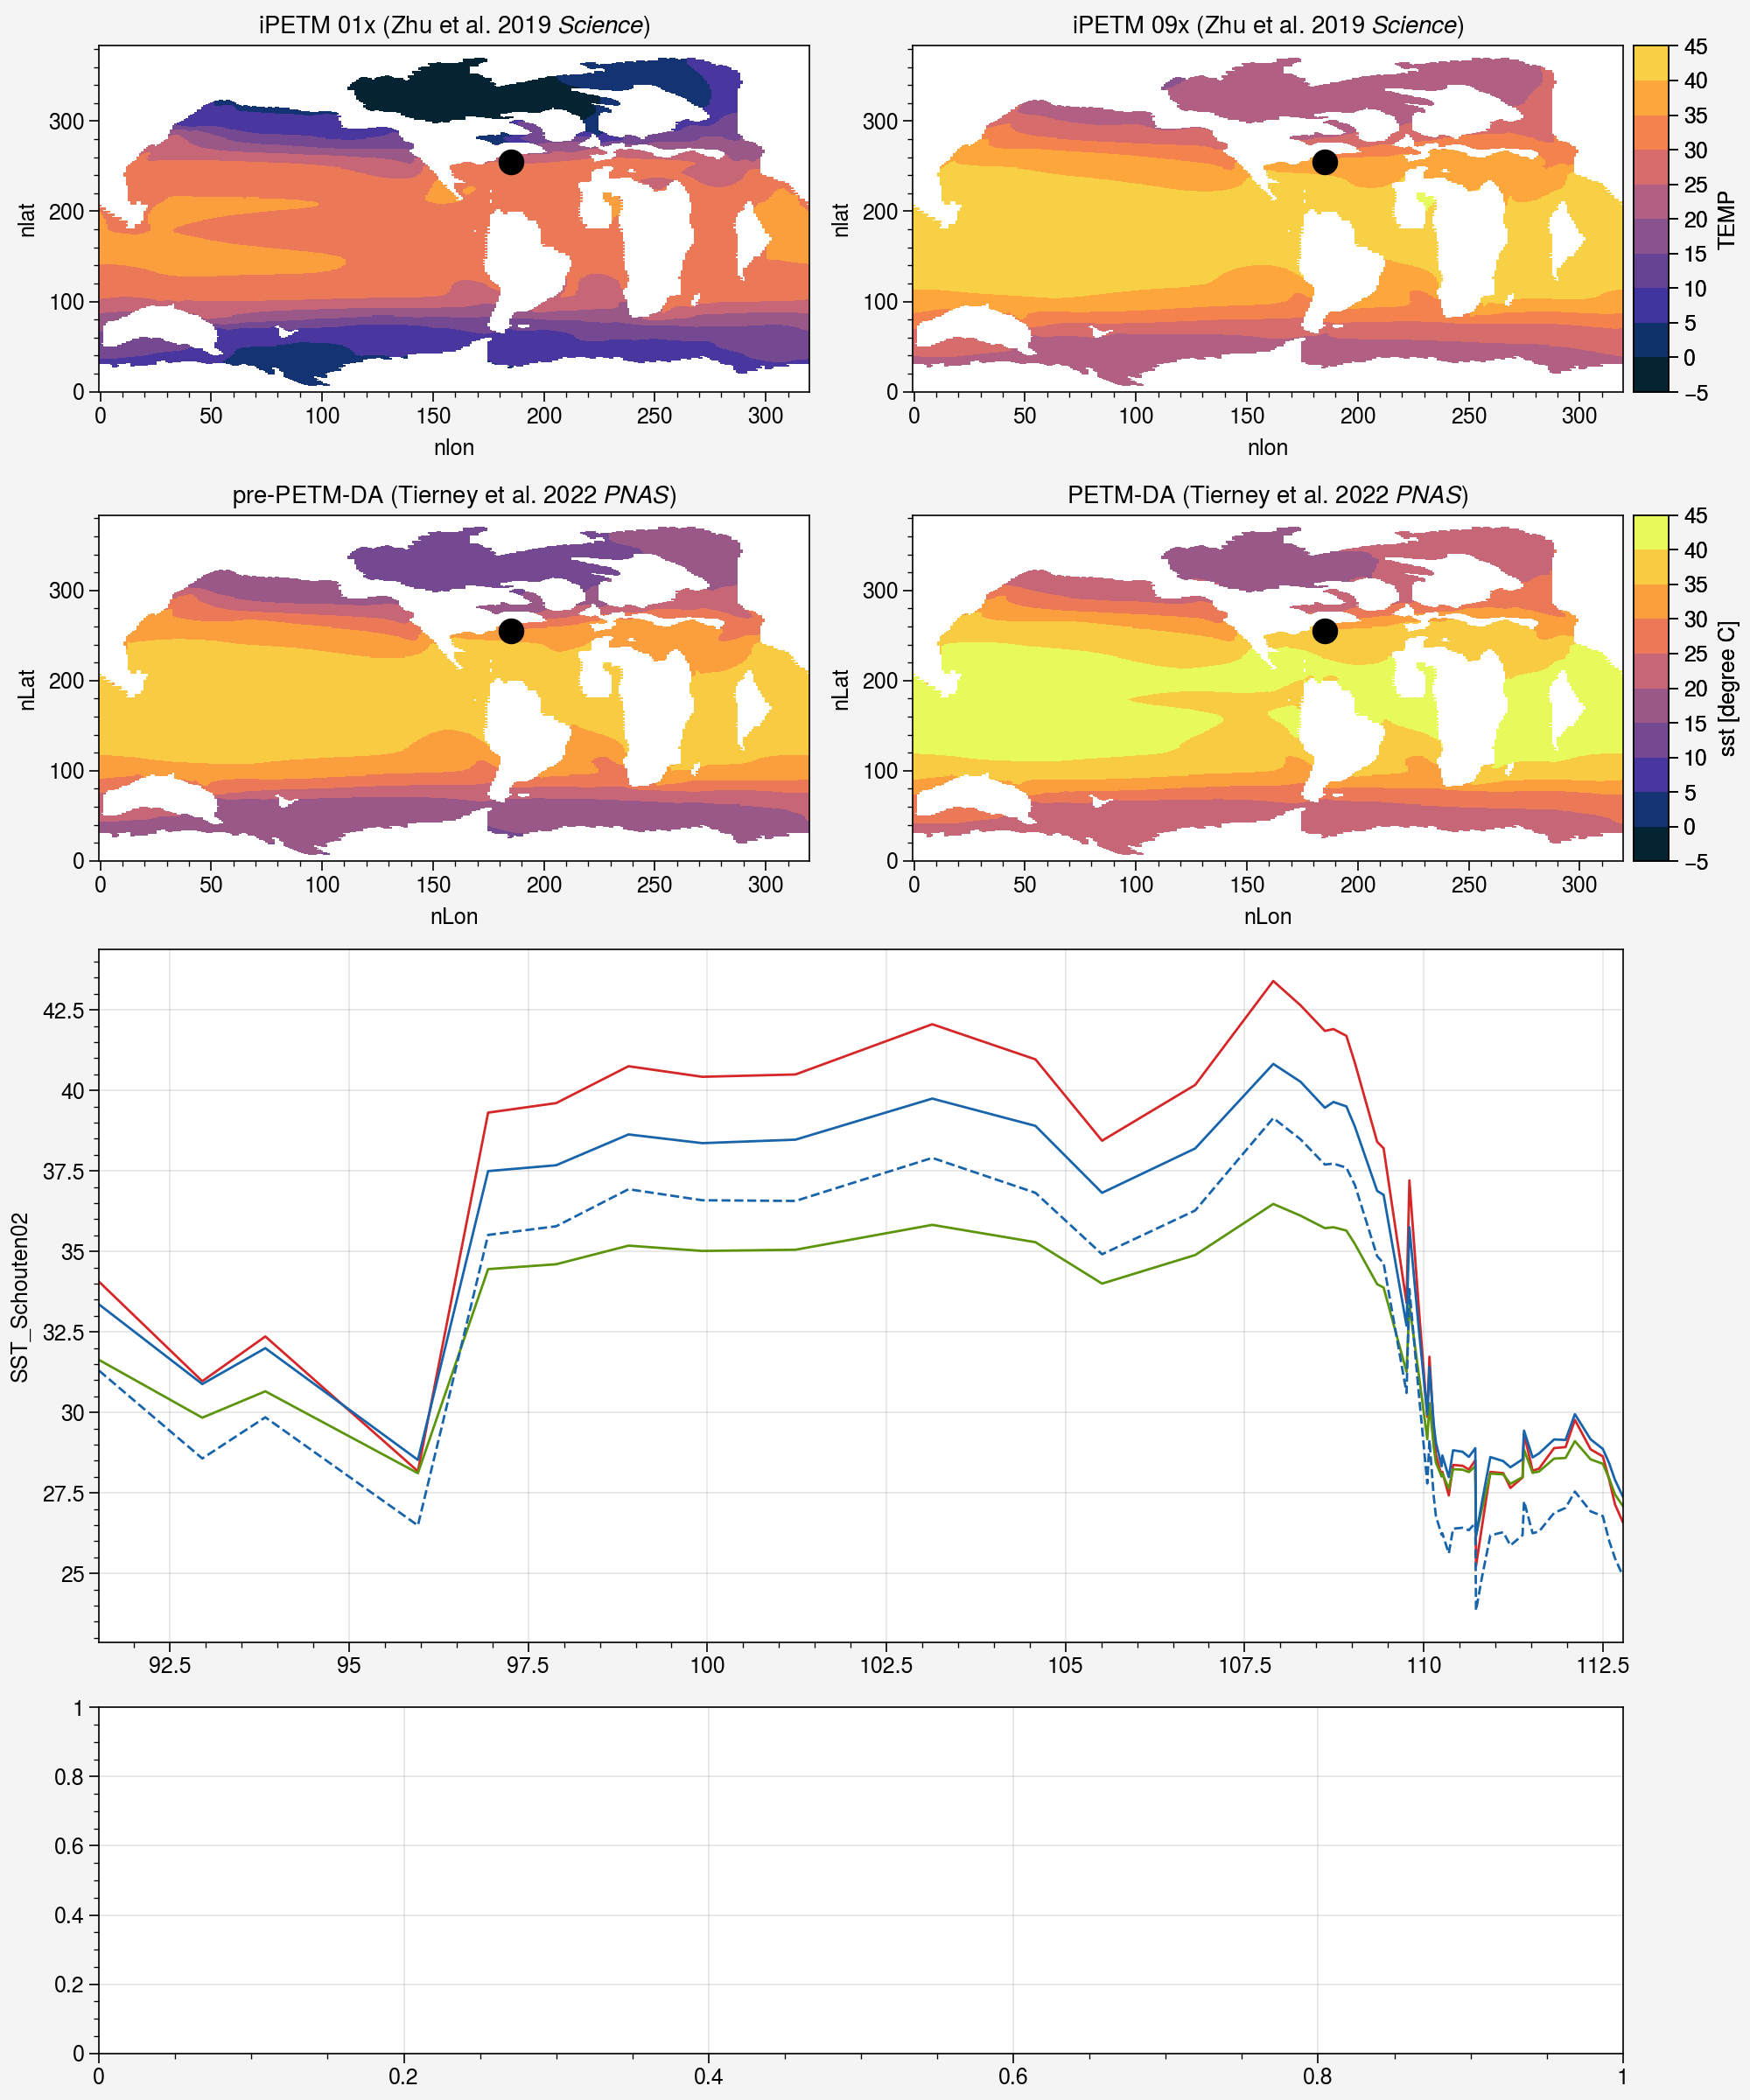

In [ ]:
WL_paleo_tex_df.columns
array = [
    [1,2],
    [3,4],
    [5,5],
    [6,6]
]
fig, axs = plot.subplots(array, figsize=(10,12),share=0,
                         hratios=[0.5,0.5,1,0.5],)



### plot iPETM data at 01x and 09x
sel_nlon = 185
sel_nlat = 255
axs[0:4].scatter(sel_nlon,sel_nlat,
                 c='k',marker='o',s=100)

iPETM_01x_ds.mean(dim='time').TEMP.plot(
    ax=axs[0],zorder=0,
    cmap='thermal',levels=np.arange(-5,50,5),
    add_colorbar=False)
axs[0].set_title('iPETM 01x (Zhu et al. 2019 ' + r'$\it{Science}$' + ')')

iPETM_09x_ds.mean(dim='time').TEMP.plot(
    ax=axs[1],zorder=0,
    cmap='thermal',levels=np.arange(-5,50,5))
axs[1].set_title('iPETM 09x (Zhu et al. 2019 ' + r'$\it{Science}$' + ')')

prePETMDA_da.plot(ax=axs[2],zorder=0,
                cmap='thermal',levels=np.arange(-5,50,5),
                add_colorbar=False)
axs[2].set_title('pre-PETM-DA (Tierney et al. 2022 ' + r'$\it{PNAS}$' + ')')

PETMDA_da.plot(ax=axs[3],zorder=0,
                cmap='thermal',levels=np.arange(-5,50,5))
axs[3].set_title('PETM-DA (Tierney et al. 2022 ' + r'$\it{PNAS}$' + ')')


ax = axs[4]

y_params = [
    'SST_Schouten02',
    'SST_Kim10',
    'SST_bsr',
    'subT_bsr',
    'invT_hier_univ_thermoT',
    'invT_hier_univ_sst',
    'invT_hier_multiv_thermoT_gdgt23ratio',
    'invT_hier_multiv_sst_gdgt23ratio',
    'invT_gen_logi_fixed_univ_thermoT',
    'invT_gen_logi_fixed_univ_sst',
    'invT_gen_logi_fixed_multiv_thermoT_gdgt23ratio',
    'invT_gen_logi_fixed_multiv_sst_gdgt23ratio',
]
plot_style_dict = {
    'invT_gen_logi_fixed_univ_thermoT': ('teal5', '--'),
    'invT_gen_logi_fixed_univ_sst': ('teal5', '-'),
    'invT_gen_logi_fixed_multiv_thermoT_gdgt23ratio': ('grape9', '--'),
    'invT_gen_logi_fixed_multiv_sst_gdgt23ratio': ('grape9', '-'),
    
    'invT_hier_univ_thermoT': ('yellow9', '--'),
    'invT_hier_univ_sst': ('yellow9', '-'),
    'invT_hier_multiv_thermoT_gdgt23ratio': ('pink9', '--'),
    'invT_hier_multiv_sst_gdgt23ratio': ('pink9', '-'),
    
    'SST_Schouten02': ('tab:red', '-'),
    'SST_Kim10': ('lime9', '-'),
    'SST_bsr': ('blue9', '-'),
    'subT_bsr': ('blue9', '--')
}
plot_x = WL_paleo_tex_df['SampleDepth'].values
model_label_list = []
color_list_for_violins = []
for i, y_param in enumerate(y_params):
    ax.plot(plot_x, WL_paleo_tex_df[y_param],
            label=y_param, 
            c=plot_style_dict.get(y_param,'gray5')[0], 
            ls=plot_style_dict.get(y_param,'gray5')[1],lw=1)
    model_label_list.append(y_param)
    color_list_for_violins.append(plot_style_dict.get(y_param,'gray5')[0])

ax.format(
    xlim=(80,115),
)

ax2 = ax.twinx()
ax2.spines['right'].set_position(('outward', 40))  # move the right spine outward
ax2.spines['right'].set_bounds(1.8,3)

plot_y = WL_paleo_tex_df['gdgt23ratio']
ax2.plot(plot_x, plot_y, color='k',
         label='GDGT-2/GDGT-3')
ax2.format(
    ylim=(1.5,6)
)
h, l = ax.get_legend_handles_labels()
axs[5].legend(h, l, loc='r', ncols=1, fontsize=8, frameon=False)

iPETM_ds_list = [iPETM_01x_ds, iPETM_03x_ds, iPETM_06x_ds, iPETM_09x_ds]
for i, iPETM_ds in enumerate(iPETM_ds_list):
    sel_nlon = 185
    sel_nlat = 255
    plot_sel_t = iPETM_ds.mean(dim='time').TEMP.sel(nlon=sel_nlon,nlat=sel_nlat).values
    ax.axhline(y=plot_sel_t, color=['red3','red5','red7','red9'][i],
               zorder=0,lw=1,alpha=0.5)
    
    ax.text(81, plot_sel_t+0.25, f'iPETM {[1,3,7,9][i]}x',
            fontsize=10,fontweight='bold',c='pink9')

PETMDA_ds_list = [prePETMDA_da, PETMDA_da]
for i, sel_da in enumerate(PETMDA_ds_list):
    sel_nlon = 185
    sel_nlat = 255
    plot_sel_t = sel_da.sel(nLon=sel_nlon,nLat=sel_nlat).values.copy()
    ax.axhline(y=plot_sel_t, color=['purple','purple'][i],
               zorder=0,lw=1,alpha=0.5)
    
    ax.text(81, plot_sel_t-1, f'{["pre-PETMDA","PETMDA"][i]}',
            fontsize=10,fontweight='bold',c='purple')
    
ax.format(
    xlim=(80,115),
    ymin=15,
    ultitle='PETM - Wilson Lake\n(Schouten et al. 2006; Sluijs et al. 2007)'
)

ax = axs[5]
### calculate T difference between pre-PETM (depth 110.5--113) and PETM (dpeth 97--109) for each model
predT_model_list = model_label_list

diff_data = {}
diff_T_column_list = []
for predT_model in predT_model_list:
    prePETM = WL_paleo_tex_df[(WL_paleo_tex_df['SampleDepth']>=110.5) 
                           & (WL_paleo_tex_df['SampleDepth']<=113)][predT_model].mean()
    PETM = WL_paleo_tex_df[(WL_paleo_tex_df['SampleDepth']>=97) 
                        & (WL_paleo_tex_df['SampleDepth']<=109)][predT_model].mean()
    diff_data[predT_model] = PETM - prePETM
    WL_paleo_tex_df[f'diffT_{predT_model}'] = WL_paleo_tex_df[predT_model] - prePETM
    diff_T_column_list.append(f'diffT_{predT_model}')

diff_data = pd.DataFrame(diff_data, index=[0])
feature = diff_T_column_list
paleo_diffT_df = WL_paleo_tex_df[(WL_paleo_tex_df['SampleDepth']>=97) 
                              & (WL_paleo_tex_df['SampleDepth']<=109)][feature].copy()

# sel_palette = ['yellow9','yellow9','pink9','pink9',
#                'tab:red','lime9','blue9','blue9']
sel_palette = color_list_for_violins
sns.stripplot(data=paleo_diffT_df,ax=ax,
              orient='v',m='.',color='black',)
sns.violinplot(data=paleo_diffT_df,ax=ax,
               orient='v',palette=sel_palette,alpha=0.5)
site_prePETMDA = prePETMDA_da.sel(nLon=sel_nlon,nLat=sel_nlat).values
site_PETMDA = PETMDA_da.sel(nLon=sel_nlon,nLat=sel_nlat).values
ax.axhline(y=(site_PETMDA - site_prePETMDA), color='purple', lw=2)
ax.text(0.01,0.1,r'$\Delta$T PETM-DA',transform=ax.transAxes,c='purple',fontweight='bold')
ax.format(
    xrotation=45,
    ylabel='$\Delta$T (°C) | PETM - pre-PETM',
    ylim=(2,15)
)

from matplotlib import patches
rect = patches.Rectangle((97, 10), 12, 35, color='gray5', alpha=0.4)
axs[4].add_patch(rect)

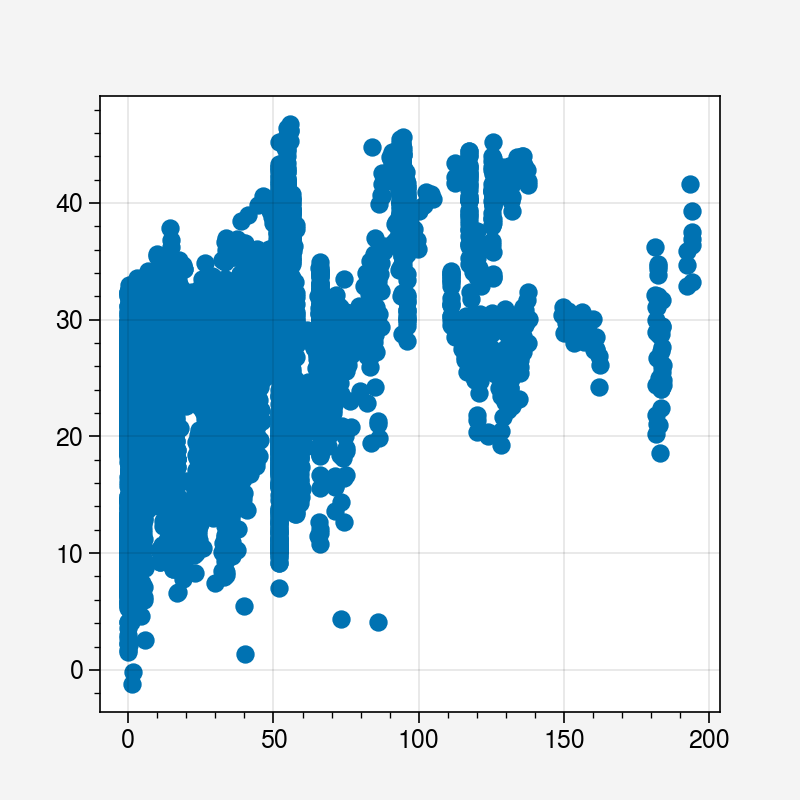

In [ ]:
plt.scatter(PhanTEX_df['Age'],PhanTEX_df['SST_Schouten02'])